### Heating Rate Analysis
2026-07-28

Aim is to vastly simplify the current analysis of circa 2024 data.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import os
from scipy.optimize import curve_fit
from scipy.constants import h, hbar, pi, k as k_B

# paths
import sys
from pathlib import Path

notebook_dir = Path.cwd()
parent_dir = notebook_dir.parent
analysis_dir = parent_dir / "analysis"

if str(parent_dir) not in sys.path:
    sys.path.append(str(parent_dir))

if str(analysis_dir) not in sys.path:
    sys.path.append(str(analysis_dir))

from analysis.constants import mK
from field_wiggle_calibration import a_amp_from_Vpp, Bamp_from_Vpp
from analysis.unitary_fermi_gas import TrappedUnitaryGas

In [2]:
### Load metadata dataframe
metadata_file = 'heating_metadata.xlsx'
metadata = pd.read_excel(metadata_file)

### Load data files
metadf =  metadata.loc[metadata['exclude'] == 0][['filename', 'B', 'barnu']]

data_folder = 'heating'

dfs = []
for row in metadf.itertuples(index=False):
    file = row.filename
    print(file)
    
    df = pd.read_table(os.path.join(data_folder, file + '.dat'), delimiter=',')
    df['filename'] = file
    df['B'] = row.B
    df['barnu'] = row.barnu
    dfs.append(df)

# Show columns
print(dfs[1].columns)

2024-03-19_L_UHfit
2024-03-21_B_UHfit
2024-03-21_D_UHfit
2024-03-26_B_UHfit
2024-03-26_C_UHfit
2024-04-03_E_UHfit
2024-04-03_F_UHfit
2024-04-04_C_UHfit
2024-04-05_C_UHfit
2024-04-10_C_UHfit
2024-04-10_D_UHfit
2024-05-09_M_UHfit
2024-05-10_R_UHfit
2024-05-10_S_UHfit
Index(['cyc', 'freq', 'amplitude', 'time', 'wait_time', 'cyc2', 'T', 'TF',
       'EF', 'EFkHz', 'ToTF', 'wx', 'wy', 'wz', 'bx', 'by', 'bz', 'q', 'mu0',
       'offs', 'fermi3', 'fermi4', 'N', 'Npix', 'ENoEF', 'EkHz', 'ENoEF2',
       'EkHz2', 'SNkB', 'tof', 'AR', 'beta_visc', 'alpha_visc', 'smomE',
       'smomEkHz', 'smomEoEFEst', 'smomEoEF', 'filename', 'B', 'barnu'],
      dtype='object')


In [3]:
def fix_units(df):
    """
    Change units in the dataframe to SI units. 
    Specifically, it converts frequency from kHz to Hz and scattering length from kHz to Hz. 
    It also calculates the scattering length amplitude (a_amp) from the voltage peak-to-peak (Vpp) and frequency (freq).
    """
    df['freq'] = df['freq'] * 1e3  # Convert kHz to Hz
    df['EF'] = df['EF'] / 1e3  # Convert kHz to Hz
    df['time'] = df['time'] * 1e-3  # Convert ms to s
    df['wait_time'] = df['wait_time'] * 1e-3  # Convert ms to s
    df['E'] = df['EkHz'] * 1e3  # Convert kHz to Hz
    
    return df

for df in dfs:
    df = fix_units(df)

In [4]:
def fit_two_points_linear(final, initial, y_name='T', x_name='time'):
    """
    Fit a linear model to two points and return the slope and intercept along with their uncertainties.
    Structured to be used in place of curve_fit when there are only two unique time points in the data.
    """
    # If there are only two unique time points, calculate the slope directly
    a = (final[y_name].mean() - initial[y_name].mean()) / (final[x_name].mean() - initial[x_name].mean())
    e_a = np.sqrt((final[y_name].sem()**2 + initial[y_name].sem()**2) / (final[x_name].mean() - initial[x_name].mean())**2)
    b = initial[y_name].mean() - a * initial[x_name].mean()
    e_b = np.sqrt(initial[y_name].sem()**2 + (e_a * initial[x_name].mean())**2)

    return [a, b], [e_a, e_b]  # popt, perr


def kF_from_EF(EF):
    """
    Calculate Fermi wavevector kF from Fermi energy EF.
    """
    kF = np.sqrt(2 * mK * EF) / hbar
    return kF


def calculate_heating_rate(group):
    """
    Calculate heating rate from a dataframe containing time and temperature data.
    """

    total_time = group['time'].max() + group['wait_time'].min()
    group['kF'] = kF_from_EF(group['EF'])

    initial = group[group['time']==group['time'].min()]
    final = group[group['time']==group['time'].max()]

    if group['time'].nunique() > 2:
        # Fit a linear model to the temperature vs time data
        popt, pcov = curve_fit(lambda t, a, b: a * t + b, 
                            group['time'], group['E'])
        perr = np.sqrt(np.diag(pcov)) 
    
    elif group['time'].nunique() == 2:
        popt, perr = fit_two_points_linear(final, initial, y_name='E', x_name='time')
    
    return pd.Series({
                    'heating_rate': popt[0], 
                    'e_heating_rate': perr[0],
                    'B': initial['B'].mean(),
                    'barnu': initial['barnu'].mean(),
                    'kFi': initial['kF'].mean(),
                    'e_kFi': initial['kF'].sem(),
                    'kFf': final['kF'].mean(),
                    'e_kFf': final['kF'].sem(),
                    'Ti': initial['T'].mean(),
                    'e_Ti': initial['T'].sem(),
                    'Tf': final['T'].mean(),
                    'e_Tf': final['T'].sem(),
                    'EFi': initial['EF'].mean(),
                    'e_EFi': initial['EF'].sem(),
                    'EFf': final['EF'].mean(),
                    'e_EFf': final['EF'].sem(),
                    'ToTFi': initial['ToTF'].mean(),
                    'e_ToTFi': initial['ToTF'].sem(),
                    'ToTFf': final['ToTF'].mean(),
                    'e_ToTFf': final['ToTF'].sem(),
                    'total_time': total_time,
                    'data_points': len(group),
                    })

results_list = [df.groupby(['freq', 'amplitude', 'filename']).apply(calculate_heating_rate) for df in dfs]

results_df = pd.concat(results_list, axis=0).reset_index()

results_df['Bamp'], _ = Bamp_from_Vpp(results_df['amplitude'], results_df['freq'])
results_df['a_amp'] = a_amp_from_Vpp(results_df['B'], results_df['amplitude'], results_df['freq'])

results_df['inv_kFa'] = 1 / results_df['kFi'].mean() / results_df['a_amp'].mean()
results_df['e_inv_kFa'] = results_df['inv_kFa'] * np.sqrt((results_df['kFi'].sem()/results_df['kFi'].mean())**2 \
                                  + (results_df['a_amp'].sem()/results_df['a_amp'].mean())**2)

### Colour plot all data

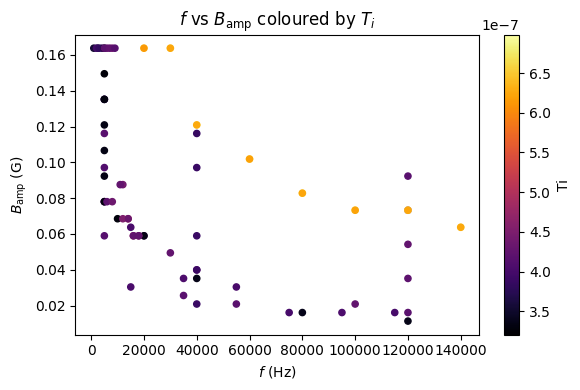

In [5]:
import matplotlib.pyplot as plt

# Create the scatter plot
scatter = results_df.plot.scatter(
    x='freq', 
    y='Bamp', 
    c='Ti', 
    cmap='inferno', 
    colorbar=True,   # Shows the color scale bar on the right
    figsize=(6, 4),
    sharex=False,     # Fixes a common matplotlib bug with x-axis labels
)

# Label the chart
scatter.set_title(r'$f$ vs $B_\mathrm{amp}$ coloured by $T_i$')
scatter.set_xlabel(r'$f$ (Hz)')
scatter.set_ylabel(r'$B_\mathrm{amp}$ (G)')

plt.tight_layout()  # Adjust subplots to fit into figure area.

plt.show()


In [6]:
# Get the top value and its total row count
most_common_freqs = results_df['freq'].value_counts()
# print(f"Frequency (Hz), # of runs: {most_common_freqs}")

### Checking amplitude scaling 
**Runs:** \
2024-03-26_B_UHfit.dat \
2024-03-26_C_UHfit.dat \
2024-04-03_F_UHfit.dat \
2024-04-05_C_UHfit.dat

C:\Users\coldatoms\AppData\Local\Temp\ipykernel_3320\3603555287.py:10: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_filtered = df[df['freq'].isin(top_3_freqs)][df['heating_rate'] > 2*df['e_heating_rate']]


Frequency: 5000.0 Hz, Fit slope: 0.1203 ± 0.0177, Intercept: 0.000361 ± 0.000334
Frequency: 40000.0 Hz, Fit slope: 0.1210 ± 0.0057, Intercept: 0.000117 ± 0.000026
Frequency: 120000.0 Hz, Fit slope: 0.0247 ± 0.0024, Intercept: 0.000015 ± 0.000002


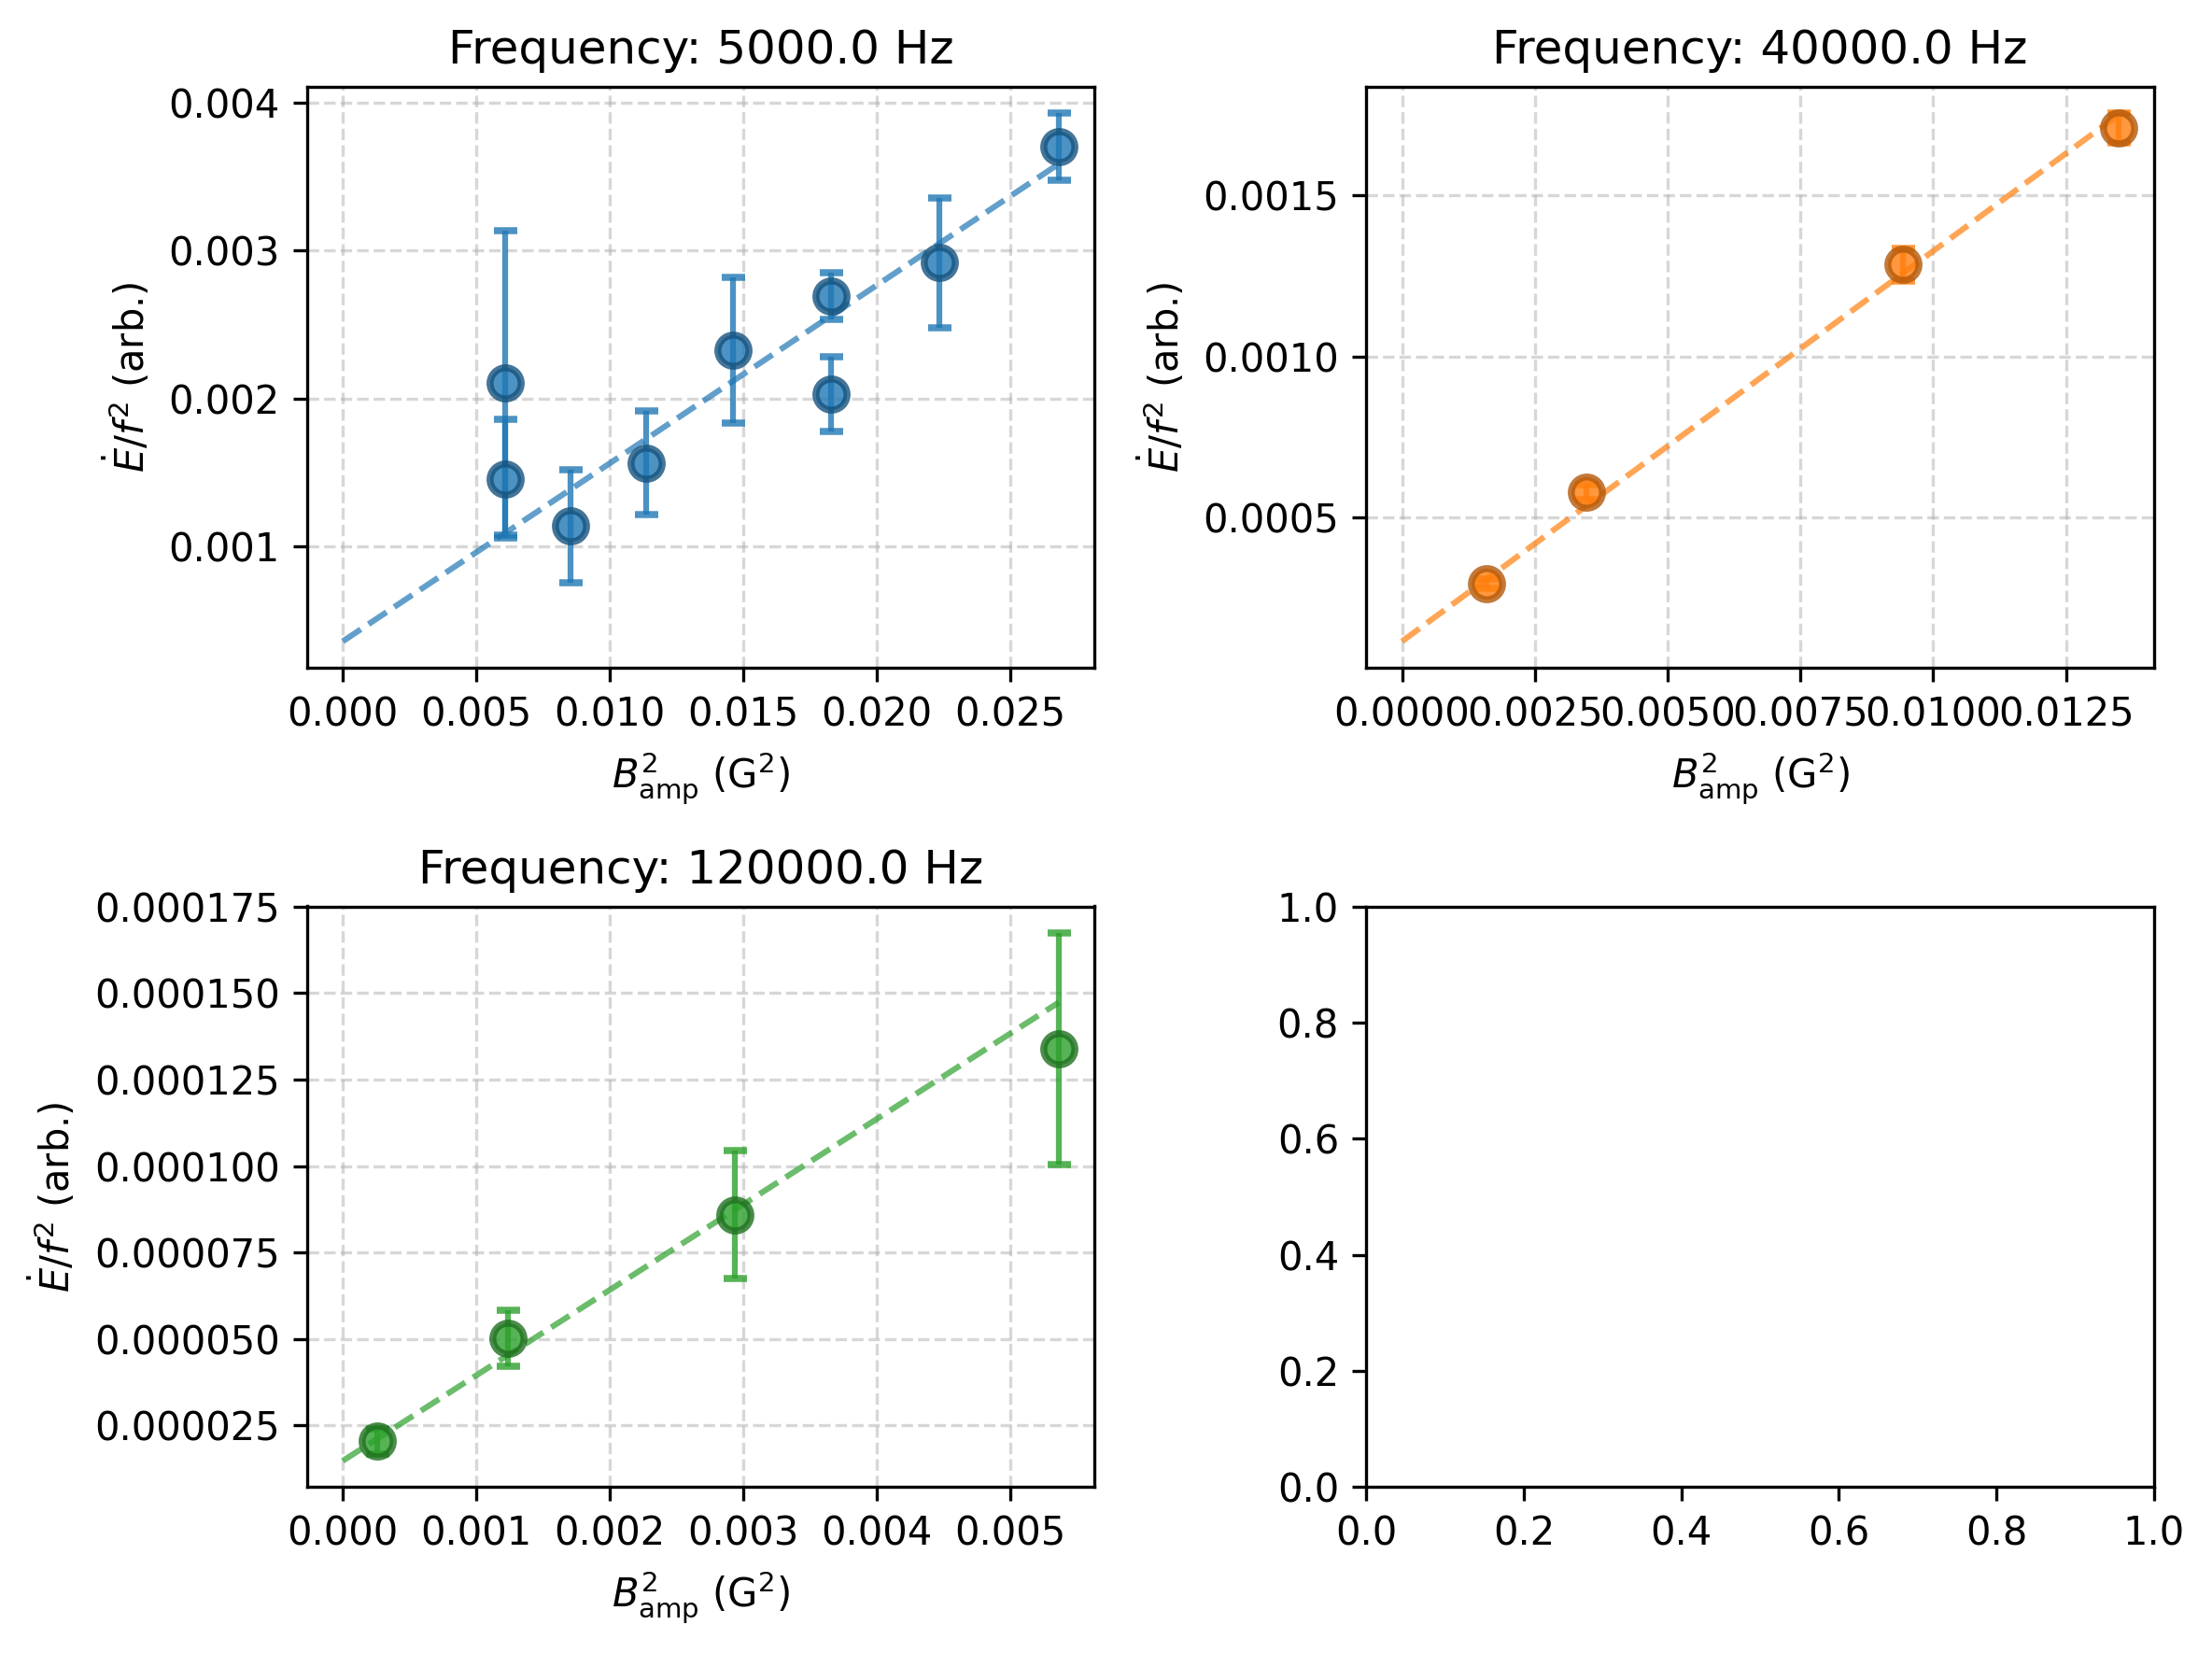

In [7]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

df = results_df.copy()

# Find the 3 most common frequencies
top_3_freqs = df['freq'].value_counts().nlargest(3).index

# Filter the DataFrame to keep only those 3 frequencies
df_filtered = df[df['freq'].isin(top_3_freqs)][df['heating_rate'] > 2*df['e_heating_rate']]

# These are datasets where the initial temperature is too different from most of the others
drop_index = [73, 12, 29, 2, 47, 55, 31, 51, 59, 26]
df_plot = df_filtered.drop(index=drop_index)

# Set font size back to default
plt.rcParams.update({'font.size': 10})

# Plot each frequency group individually to assign distinct colors
fig, axes = plt.subplots(2,2, figsize=(8, 6), dpi=300)
axs = axes.flatten()  
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # High-contrast distinct colors

for i, freq_val in enumerate(top_3_freqs):
    # Filter data for just this specific frequency
    group = df_plot[df_plot['freq'] == freq_val]

    # Calculate a 30% darker version of the base color
    rgb = mcolors.to_rgb(colors[i])
    dark_edge_color = [c * 0.7 for c in rgb]  # Multiply by 0.7 to dim it
    
    axs[i].errorbar(
        x=group['Bamp']**2,
        y=group['heating_rate']/group['freq']**2,
        yerr=group['e_heating_rate']/group['freq']**2,
        fmt='o',                # 'none' completely hides the internal errorbar marker
        color=colors[i],
        markeredgecolor=dark_edge_color,  
        capsize=3,
        alpha=0.8, 
        markeredgewidth=1.8,
        markersize=8,                      # Controls marker size
        label=f'{freq_val} kHz'     # Add a label for the legend
    )

    popt, pcov = curve_fit(lambda x, m, b: m * x + b,
                            group['Bamp']**2, 
                            group['heating_rate']/group['freq']**2, 
                            sigma=group['e_heating_rate']/group['freq']**2
                           )
    perr = np.sqrt(np.diag(pcov))

    a_sqs = np.linspace(0, group['Bamp'].max()**2, 100)

    axs[i].plot(a_sqs, np.polyval(popt, a_sqs), color=colors[i], linestyle='--', alpha=0.7)
    
    print(f"Frequency: {freq_val} Hz, Fit slope: {popt[0]:.4f} ± {perr[0]:.4f}, Intercept: {popt[1]:.6f} ± {perr[1]:.6f}")

    # TUG = TrappedUnitaryGas(ToTF=group['ToTFi'].mean(), 
    #                         EF=group['EFi'].mean(),
    #                         banru=group['barnu'].mean()
    #                         )
    # Edot = TUG.calc_Edot(nu=group['freq'].mean())


# Label the chart
for ax in axs[:-1]:
    ax.set_title(f'Frequency: {top_3_freqs[axs.tolist().index(ax)]} Hz')
    ax.set_ylabel(r'$\dot{E}/f^2$ (arb.)')
    ax.set_xlabel(r'$B_\mathrm{amp}^2$ (G$^2$)')
    ax.grid(True, linestyle='--', alpha=0.5)
    # ax.legend(title='Frequencies', loc='lower right')

fig.tight_layout()  # Adjust subplots to fit into figure area.
plt.show()


In [8]:
df_plot[['freq','amplitude','ToTFi','heating_rate','filename']].sort_values(by=['freq','amplitude'])
df_plot['filename'].unique()

array(['2024-03-26_B_UHfit', '2024-03-26_C_UHfit', '2024-04-03_F_UHfit',
       '2024-04-05_C_UHfit'], dtype=object)

In [9]:
ToTF = 0.58
EF = 19e3
barnu = 305

TUG = TrappedUnitaryGas(ToTF=ToTF, EF=EF, barnu=barnu)

c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:34: RuntimeWarning: divide by zero encountered in scalar divide
  return (4*pi)/((3*pi**2)* eos_ufg(betamu))**(2/3)


c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:109: RuntimeWarning: invalid value encountered in scalar divide
  Edot_C = 9*pi*(T*betaomega)**2/(betaomega)**(3/2) * pifactors * C
c:\Users\coldatoms\Documents\cjdGitHub\Fast-Modulation-Contact-Correlation-Project\analysis\unitary_fermi_gas.py:441: RuntimeWarning: invalid value encountered in divide
  self.zetaDrude = self.EdotDrude/self.A**2 * (self.lambda_T**2*self.kF**2)/(9*pi*nus**2*2*self.Ns)


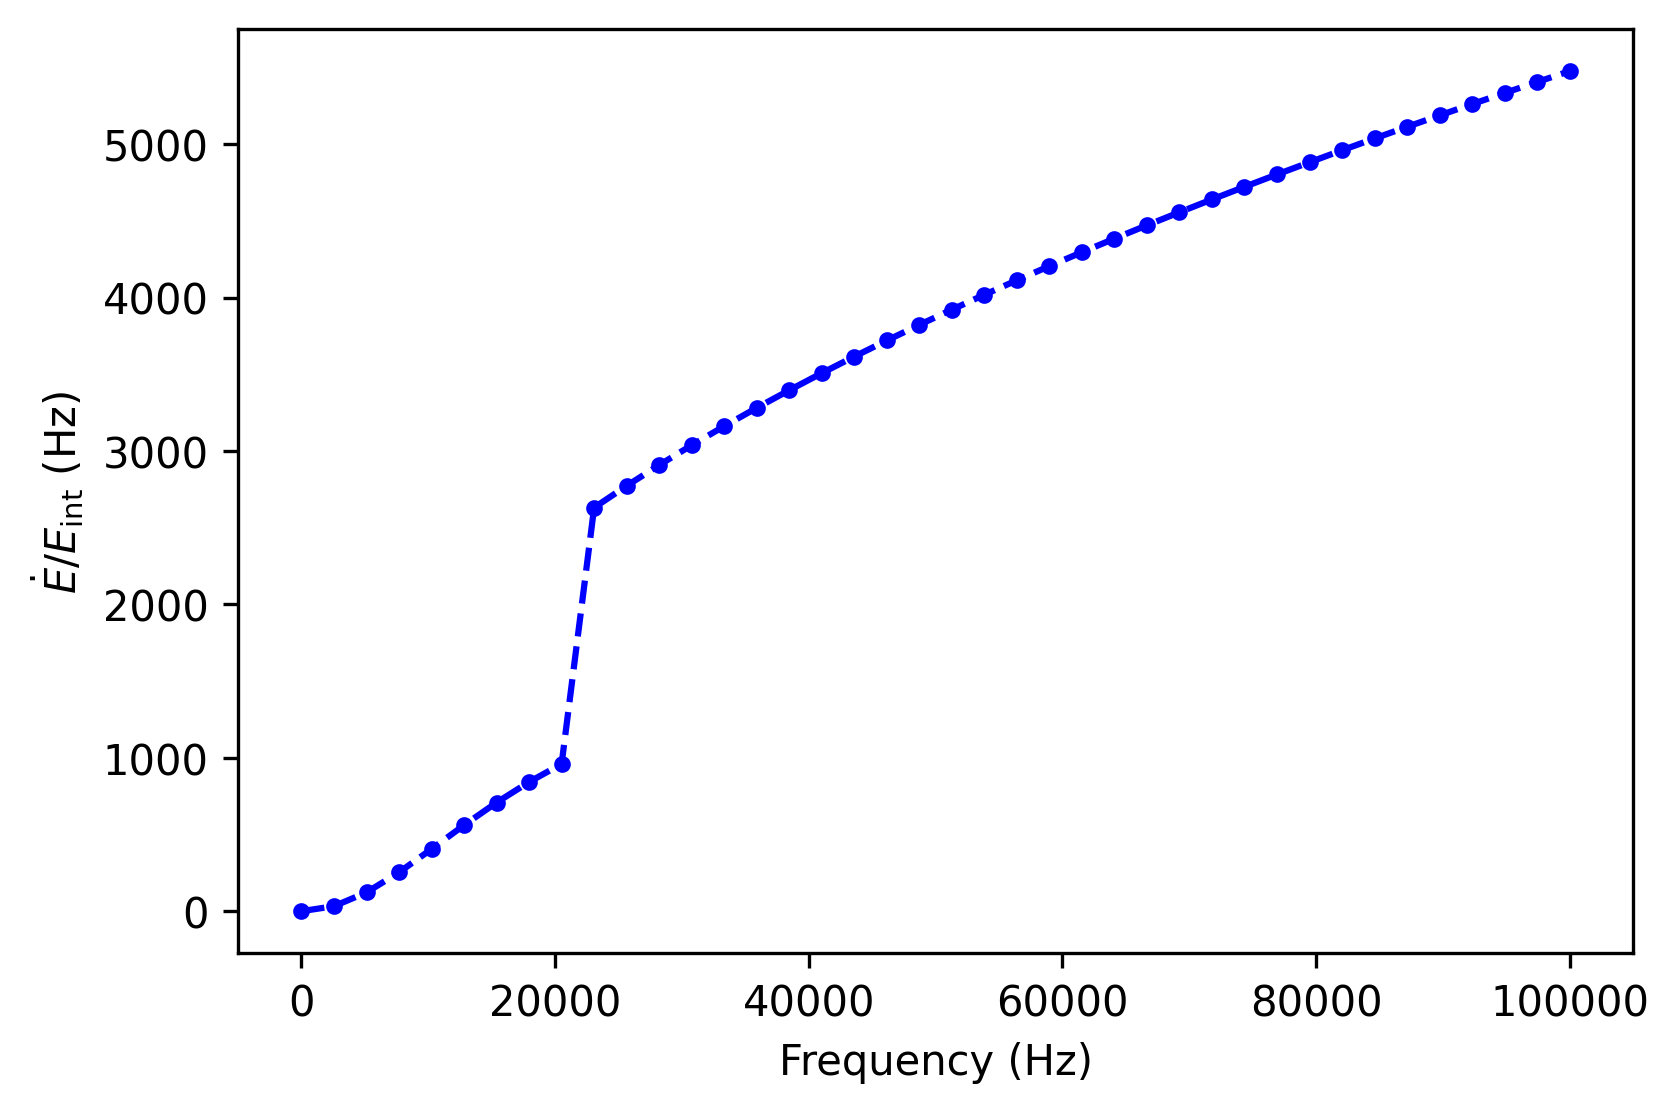

In [10]:
TUG.modulate_field(np.linspace(0, 100e3, 40))

plt.figure(figsize=(6, 4), dpi=300)
plt.plot(TUG.nus, TUG.Edot*2*TUG.Ns/TUG.Epot, 'b--')
plt.plot(TUG.nus, TUG.Edot*2*TUG.Ns/TUG.Epot, 'b.')

plt.xlabel('Frequency (Hz)')
plt.ylabel(r'$\dot{E}/E_\mathrm{int}$ (Hz)')

plt.show()

In [11]:
TUG.kF * TUG.lambda_T
TUG.betamu * TUG.T
TUG.Ns

40291.18443100221